# Compare Auction Values

In [1]:
import pandas as pd
import seaborn as sns
pd.options.display.precision = 2
import matplotlib.pyplot as plt
import json

In [2]:
League_path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Imaginary_Hammers/'

In [3]:
Full_Merge_path = League_path+'/Full_Merge.csv'

In [4]:
TeamID = 240

In [5]:
Replacement_Level_Recalc_path = League_path+'/Recalc_Replacement_Level.csv'

In [6]:
Target_Stats_path = League_path+'/Target_Stats_dict.json'

In [7]:
Replacement_Level_df = pd.read_csv(Replacement_Level_Recalc_path)

In [8]:
with open(Target_Stats_path, 'r') as f:
    data = json.load(f)
Target_Stats_df = pd.json_normalize(data)

In [9]:
Player_id_cols = [
    'FG ID','Name','Team','Ottoneu ID','Ottoneu Positions'
]

In [10]:
Fantasy_Team_ID_cols = [
    'TeamID', 'Team Name',
]

In [11]:
Games_IP_Targets = {
    'C':162,
    '1B':162,
    '2B':162,
    '3B':162,
    'SS':162,
    'MI':480, #total 2B SS MI
    'OF':810, #total
    'Util':1776, #total all hitters
    'IP':1500
}

In [12]:
Full_Merge_df = pd.read_csv(Full_Merge_path)
Full_Merge_df['FG ID'] = Full_Merge_df['FG ID'].astype(str)
Full_Merge_df['FG ID'] = Full_Merge_df['FG ID'].str.replace('.0','')
Full_Merge_df['Ottoneu ID'] = Full_Merge_df['Ottoneu ID'].astype(str)
Full_Merge_df['Ottoneu ID'] = Full_Merge_df['Ottoneu ID'].str.replace('.0','')

In [13]:
Full_Merge_sorted_df = Full_Merge_df.sort_values(by=['TOTAL_SGP_Val_mySGP'],ascending=False)

In [14]:
def quick_plotting_fn(quick_plot):
    fig = plt.figure(figsize=(10,5))
    ax1 = fig.add_subplot(111)
    ax1.errorbar(
        y=quick_plot['Name'],
        x=quick_plot['Ottoneu_Avg'],
        xerr=[
            quick_plot['Ottoneu_Avg']-quick_plot['Ottoneu_Min'],
            quick_plot['Ottoneu_Max']-quick_plot['Ottoneu_Avg']
        ],
        fmt='o',
        color='blue',
        label='4x4 Avg, Min, Max'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Ottoneu_Med'],
        marker='^',
        color='black',
        label='4x4 Median'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Salary'],
        marker='$\\$$',
        s=150,
        color='red',
        label='Current Salary'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Dollars_FGAV'],
        marker='$FG$',
        s=150,
        color='green',
        label='FG Auction Calc.'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Dollars_Vibbot'],
        marker='+',
        s=100,
        color='tab:brown',
        label='Secret Sauce V'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['TOTAL_SGP_Val_mySGP'],
        marker='*',
        s=100,
        color='tab:pink',
        label='Secret Sauce C'
    )
    ax1.set_ylabel('Player')
    ax1.invert_yaxis()
    ax1.set_xlabel('Dollars')
    ax1.legend(loc='lower right')
    plt.tick_params(axis='y', which='major', labelsize=7)
    plt.show()

In [15]:
This_team_df = Full_Merge_sorted_df[Full_Merge_sorted_df['TeamID'] == TeamID]

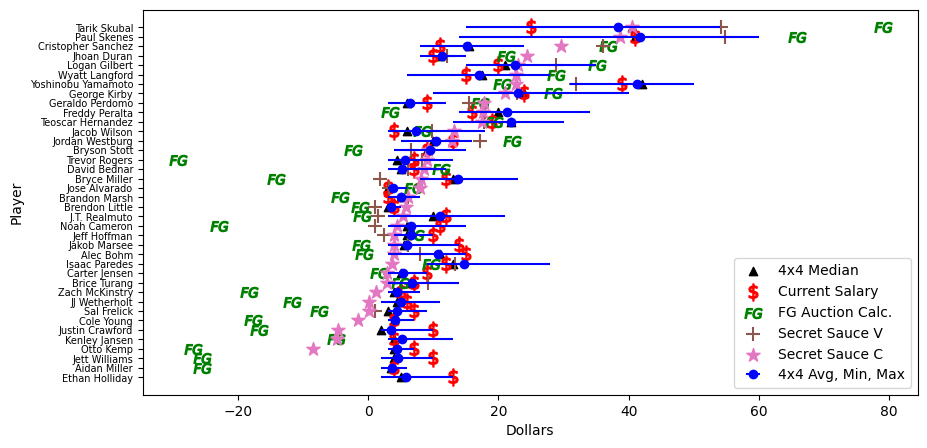

In [16]:
quick_plotting_fn(This_team_df)

In [17]:
Target_Stats_df.head()

,Target Pts,R,HR,OBP,SLG,K,HR9,ERA,WHIP
0,10.44,1073.34,323.02,0.34,0.46,1634.48,0.99,3.38,1.13


In [18]:
Replacement_Level_df[['Ottoneu Positions','R_mySGP','HR_mySGP','OBP_mySGP','SLG_mySGP','SO_mySGP','HR9_mySGP','ERA_mySGP','WHIP_mySGP']]

,Ottoneu Positions,R_mySGP,HR_mySGP,OBP_mySGP,SLG_mySGP,SO_mySGP,HR9_mySGP,ERA_mySGP,WHIP_mySGP
0,C,49.39,12.67,0.31,0.40,NaN,NaN,NaN,NaN
1,1B,66.76,18.54,0.33,0.43,NaN,NaN,NaN,NaN
2,2B,63.02,12.64,0.32,0.39,NaN,NaN,NaN,NaN
3,SS,47.39,8.64,0.31,0.38,NaN,NaN,NaN,NaN
4,3B,63.92,17.69,0.32,0.42,NaN,NaN,NaN,NaN
5,MI,53.49,10.94,0.31,0.39,NaN,NaN,NaN,NaN
6,OF,54.73,12.01,0.31,0.40,NaN,NaN,NaN,NaN
7,Util,48.12,10.82,0.31,0.39,NaN,NaN,NaN,NaN
8,SP,NaN,NaN,NaN,NaN,87.82,1.14,4.01,1.27
9,RP,NaN,NaN,NaN,NaN,74.40,1.26,4.37,1.36


In [19]:
Replacement_Level_df[['Ottoneu Positions','R_SGP_raw_mySGP','HR_SGP_raw_mySGP','OBP_SGP_raw_mySGP','SLG_SGP_raw_mySGP','SO_SGP_raw_mySGP','HR9_SGP_raw_mySGP','ERA_SGP_raw_mySGP','WHIP_SGP_raw_mySGP']]

,Ottoneu Positions,R_SGP_raw_mySGP,HR_SGP_raw_mySGP,OBP_SGP_raw_mySGP,SLG_SGP_raw_mySGP,SO_SGP_raw_mySGP,HR9_SGP_raw_mySGP,ERA_SGP_raw_mySGP,WHIP_SGP_raw_mySGP
0,C,1.95,1.10,-1.38e-01,-0.14,NaN,NaN,NaN,NaN
1,1B,2.64,1.61,-5.11e-03,0.02,NaN,NaN,NaN,NaN
2,2B,2.49,1.10,-8.23e-02,-0.18,NaN,NaN,NaN,NaN
3,SS,1.87,0.75,-2.21e-01,-0.31,NaN,NaN,NaN,NaN
4,3B,2.53,1.54,-6.64e-02,-0.08,NaN,NaN,NaN,NaN
5,MI,2.12,0.95,-1.74e-01,-0.24,NaN,NaN,NaN,NaN
6,OF,2.16,1.04,-1.56e-01,-0.16,NaN,NaN,NaN,NaN
7,Util,1.90,0.94,-1.94e-01,-0.21,NaN,NaN,NaN,NaN
8,SP,NaN,NaN,NaN,NaN,1.85,-0.19,-0.18,-0.22
9,RP,NaN,NaN,NaN,NaN,1.57,0.54,0.25,0.25


In [20]:
Team_hitter_groupby = Full_Merge_sorted_df[~Full_Merge_sorted_df['Repl_Pos_mySGP'].isin(['SP', 'RP'])].groupby(['Team Name'])[[
    # 'Name',
    # 'Team',
    # 'Ottoneu Positions',
    # 'Repl_Pos_mySGP',
    'G_mySGP',
    'HR_mySGP',
    'R_mySGP',
    'OBP_mySGP',
    'SLG_mySGP',
    # 'IP_mySGP',
    'R_SGP_raw_mySGP',
    'HR_SGP_raw_mySGP',
    'OBP_SGP_raw_mySGP',
    'SLG_SGP_raw_mySGP',
    'R_SGP_norm_mySGP',
    'HR_SGP_norm_mySGP',
    'OBP_SGP_norm_mySGP',
    'SLG_SGP_norm_mySGP',
    # 'SO_mySGP',
    # 'HR9_mySGP',
    # 'ERA_mySGP',
    # 'WHIP_mySGP',
    # 'SO_SGP_Val_mySGP',
    # 'HR9_SGP_Val_mySGP',
    # 'ERA_SGP_Val_mySGP',
    # 'WHIP_SGP_Val_mySGP',
    'TOTAL_SGP_raw_mySGP',
    'TOTAL_SGP_mySGP',
    # 'TOTAL_SGP_Rank_mySGP',
    # 'TOTAL_SGP_Val_mySGP',
    # 'Dollars_FGAV',
    # 'Dollars_Vibbot',
    # 'Ottoneu_Avg',
    # 'Ottoneu_Med',
    # 'Ottoneu_Min',
    # 'Ottoneu_Max',
    # 'Ottoneu_L10',
    # 'Roster%',
    # 'TeamID',
    # 'Team Name',
    # 'Salary'
    ]].sum()



In [21]:
Team_hitter_groupby

,G_mySGP,HR_mySGP,R_mySGP,OBP_mySGP,SLG_mySGP,R_SGP_raw_mySGP,HR_SGP_raw_mySGP,OBP_SGP_raw_mySGP,SLG_SGP_raw_mySGP,R_SGP_norm_mySGP,HR_SGP_norm_mySGP,OBP_SGP_norm_mySGP,SLG_SGP_norm_mySGP,TOTAL_SGP_raw_mySGP,TOTAL_SGP_mySGP
Team Name,,,,,,,,,,,,,,,
Carlos Pérez's K-Dance,2091.32,303.63,1067.02,5.07,6.68,42.20,26.38,-2.54,-1.15,7.69,9.64,0.58,3.71,64.90,21.63
Chili Dog MVP,1928.76,280.74,965.94,5.32,7.06,38.21,24.39,-3.80,-1.17,0.91,5.18,-0.17,3.55,57.62,9.47
Hornswogglers,3055.94,419.44,1635.19,8.17,10.41,64.68,36.45,0.66,-1.00,9.81,10.66,5.43,6.74,100.79,32.64
Jack Klugman's Second Best Lung,2295.47,363.76,1192.66,6.04,8.14,47.17,31.61,-2.50,1.34,5.40,9.89,1.37,6.32,77.61,22.98
Largely Indistinguishables,2283.45,259.55,1180.37,6.18,7.63,46.69,22.55,0.15,-3.68,7.20,3.87,3.83,2.31,65.71,17.20
Roar from 34,2340.66,339.73,1251.51,5.84,7.66,49.50,29.52,-0.12,0.74,11.76,10.56,3.50,5.87,79.65,31.69
Roberto Big Piece and the 69ers,2392.31,380.14,1298.55,5.91,7.90,51.36,33.03,1.67,2.91,11.75,13.34,5.33,8.19,88.98,38.62
Smoak and Mirrors,2434.61,342.45,1262.48,6.21,8.02,49.94,29.76,0.87,-0.51,8.62,9.70,4.38,5.29,80.06,28.00
St. CGT VI,2861.02,430.22,1515.15,7.60,9.82,59.93,37.38,3.74,1.62,10.64,13.31,8.50,8.17,102.68,40.62


In [22]:
pd.DataFrame(((Team_hitter_groupby.loc['Largely Indistinguishables']/Team_hitter_groupby.sum())*100)[['G_mySGP',
    'HR_mySGP',
    'R_mySGP',
    'OBP_mySGP',
    'SLG_mySGP']]).T

,G_mySGP,HR_mySGP,R_mySGP,OBP_mySGP,SLG_mySGP
0,8.05,6.16,7.88,8.36,7.89


<Axes: >

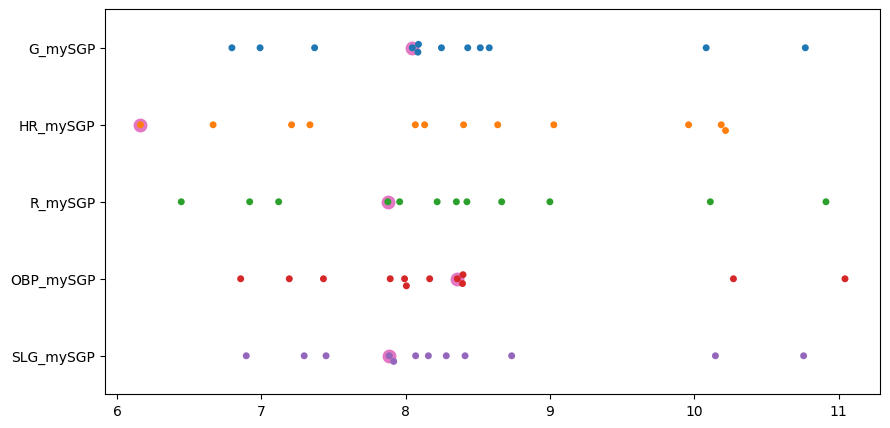

In [23]:
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(111)
sns.swarmplot(pd.DataFrame(((Team_hitter_groupby.loc['Largely Indistinguishables']/Team_hitter_groupby.sum())*100)[['G_mySGP',
    'HR_mySGP',
    'R_mySGP',
    'OBP_mySGP',
    'SLG_mySGP',
    ]]).T,orient='h',ax=ax1,color='tab:pink',size=10)
sns.swarmplot(((Team_hitter_groupby/Team_hitter_groupby.sum())*100)[['G_mySGP',
    'HR_mySGP',
    'R_mySGP',
    'OBP_mySGP',
    'SLG_mySGP']],orient='h',ax=ax1)

In [24]:
# fig = plt.figure(figsize=(10,5))
# ax1 = fig.add_subplot(111)
# sns.swarmplot(pd.DataFrame(((Team_hitter_groupby.loc['Largely Indistinguishables']/Team_hitter_groupby.sum())*100)[['R_SGP_raw_mySGP',
#     'HR_SGP_raw_mySGP',
#     'OBP_SGP_raw_mySGP',
#     'SLG_SGP_raw_mySGP',
#     'TOTAL_SGP_raw_mySGP']]).T,orient='h',ax=ax1,color='tab:pink',size=10)
# sns.swarmplot(((Team_hitter_groupby/Team_hitter_groupby.sum())*100)[['R_SGP_raw_mySGP',
#     'HR_SGP_raw_mySGP',
#     'OBP_SGP_raw_mySGP',
#     'SLG_SGP_raw_mySGP',
#     'TOTAL_SGP_raw_mySGP']],orient='h',ax=ax1)

<Axes: >

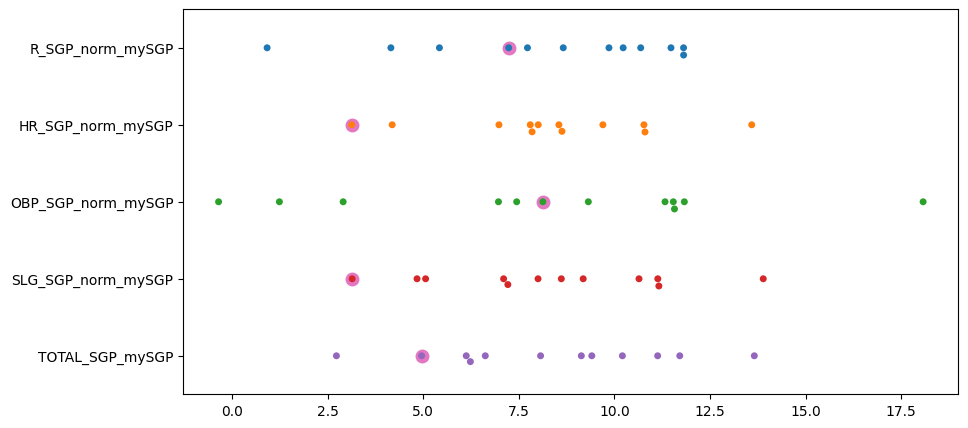

In [25]:
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(111)
sns.swarmplot(pd.DataFrame(((Team_hitter_groupby.loc['Largely Indistinguishables']/Team_hitter_groupby.sum())*100)[['R_SGP_norm_mySGP',
    'HR_SGP_norm_mySGP',
    'OBP_SGP_norm_mySGP',
    'SLG_SGP_norm_mySGP',
    'TOTAL_SGP_mySGP']]).T,orient='h',ax=ax1,color='tab:pink',size=10)
sns.swarmplot(((Team_hitter_groupby/Team_hitter_groupby.sum())*100)[['R_SGP_norm_mySGP',
    'HR_SGP_norm_mySGP',
    'OBP_SGP_norm_mySGP',
    'SLG_SGP_norm_mySGP',
    'TOTAL_SGP_mySGP']],orient='h',ax=ax1)

In [26]:
Team_pitcher_groupby = Full_Merge_sorted_df[Full_Merge_sorted_df['Repl_Pos_mySGP'].isin(['SP', 'RP'])].groupby(['Team Name'])[[
    # 'Name',
    # 'Team',
    # 'Ottoneu Positions',
    # 'Repl_Pos_mySGP',
    # 'G_mySGP',
    # 'HR_mySGP',
    # 'R_mySGP',
    # 'OBP_mySGP',
    # 'SLG_mySGP',
    'IP_mySGP',
    # 'R_SGP_raw_mySGP',
    # 'HR_SGP_raw_mySGP',
    # 'OBP_SGP_raw_mySGP',
    # 'SLG_SGP_raw_mySGP',
    # 'R_SGP_norm_mySGP',
    # 'HR_SGP_norm_mySGP',
    # 'OBP_SGP_norm_mySGP',
    # 'SLG_SGP_norm_mySGP',
    'SO_mySGP',
    'HR9_mySGP',
    'ERA_mySGP',
    'WHIP_mySGP',
    'SO_SGP_raw_mySGP',
    'HR9_SGP_raw_mySGP',
    'ERA_SGP_raw_mySGP',
    'WHIP_SGP_raw_mySGP',
    'SO_SGP_norm_mySGP',
    'HR9_SGP_norm_mySGP',
    'ERA_SGP_norm_mySGP',
    'WHIP_SGP_norm_mySGP',
    'TOTAL_SGP_raw_mySGP',
    'TOTAL_SGP_mySGP',
    # 'TOTAL_SGP_Rank_mySGP',
    # 'TOTAL_SGP_Val_mySGP',
    # 'Dollars_FGAV',
    # 'Dollars_Vibbot',
    # 'Ottoneu_Avg',
    # 'Ottoneu_Med',
    # 'Ottoneu_Min',
    # 'Ottoneu_Max',
    # 'Ottoneu_L10',
    # 'Roster%',
    # 'TeamID',
    # 'Team Name',
    # 'Salary'
    ]].sum()

<Axes: >

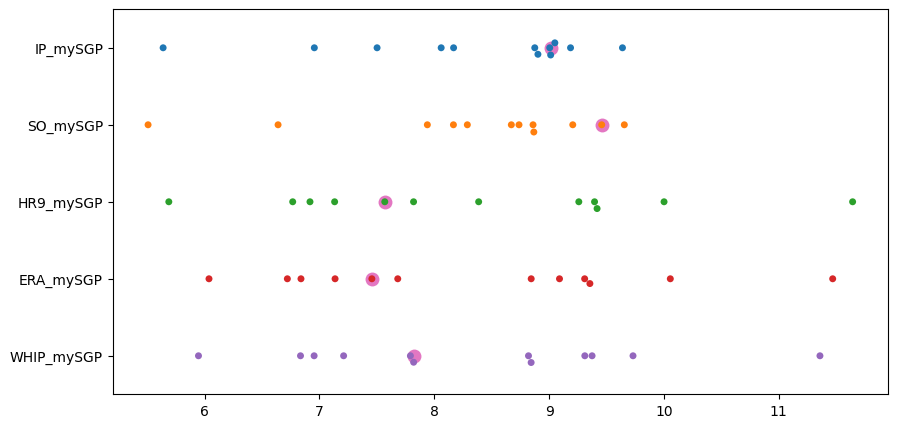

In [27]:
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(111)
sns.swarmplot(pd.DataFrame(((Team_pitcher_groupby.loc['Largely Indistinguishables']/Team_pitcher_groupby.sum())*100)[['IP_mySGP',
    'SO_mySGP',
    'HR9_mySGP',
    'ERA_mySGP',
    'WHIP_mySGP',
    ]]).T,orient='h',ax=ax1,color='tab:pink',size=10)
sns.swarmplot(((Team_pitcher_groupby/Team_pitcher_groupby.sum())*100)[['IP_mySGP',
    'SO_mySGP',
    'HR9_mySGP',
    'ERA_mySGP',
    'WHIP_mySGP']],orient='h',ax=ax1)

In [28]:
# fig = plt.figure(figsize=(10,5))
# ax1 = fig.add_subplot(111)
# sns.swarmplot(pd.DataFrame(((Team_pitcher_groupby.loc['Largely Indistinguishables']/Team_pitcher_groupby.sum())*100)[['SO_SGP_raw_mySGP',
#     'HR9_SGP_raw_mySGP',
#     'ERA_SGP_raw_mySGP',
#     'WHIP_SGP_raw_mySGP',
#     'TOTAL_SGP_raw_mySGP']]).T,orient='h',ax=ax1,color='tab:pink',size=10)
# sns.swarmplot(((Team_pitcher_groupby/Team_pitcher_groupby.sum())*100)[['SO_SGP_raw_mySGP',
#     'HR9_SGP_raw_mySGP',
#     'ERA_SGP_raw_mySGP',
#     'WHIP_SGP_raw_mySGP',
#     'TOTAL_SGP_raw_mySGP']],orient='h',ax=ax1)

<Axes: >

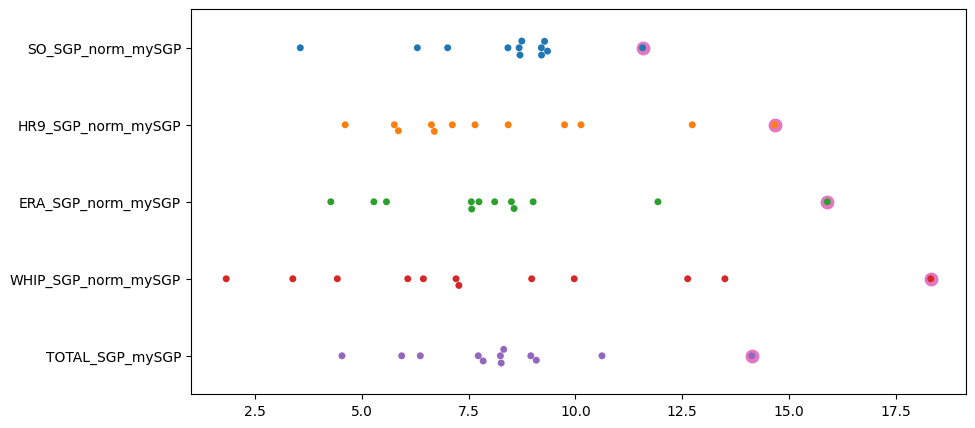

In [29]:
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(111)
sns.swarmplot(pd.DataFrame(((Team_pitcher_groupby.loc['Largely Indistinguishables']/Team_pitcher_groupby.sum())*100)[['SO_SGP_norm_mySGP',
    'HR9_SGP_norm_mySGP',
    'ERA_SGP_norm_mySGP',
    'WHIP_SGP_norm_mySGP',
    'TOTAL_SGP_mySGP']]).T,orient='h',ax=ax1,color='tab:pink',size=10)
sns.swarmplot(((Team_pitcher_groupby/Team_pitcher_groupby.sum())*100)[['SO_SGP_norm_mySGP',
    'HR9_SGP_norm_mySGP',
    'ERA_SGP_norm_mySGP',
    'WHIP_SGP_norm_mySGP',
    'TOTAL_SGP_mySGP']],orient='h',ax=ax1)